# Merton Generated Close Prices
Exploratory analysis of `data/generated/merton/generated_close.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

META_COLS = ['window_idx', 'sample_idx', 'file', 'window_start']

df = pd.read_csv('./data/generated/merton/generated_close.csv')
step_cols = [c for c in df.columns if c.startswith('step_')]

print(f'Rows: {len(df):,}  |  Time steps: {len(step_cols)}')
print(f'Unique files : {df["file"].nunique()}')
print(f'Unique windows: {df["window_idx"].nunique()}')
print(f'Samples per window (first window): {(df["window_idx"] == 0).sum()}')
df[META_COLS].head(4)

Rows: 1,475,450  |  Time steps: 512
Unique files : 354
Unique windows: 157
Samples per window (first window): 17700


,window_idx,sample_idx,file,window_start
0,0,0,AAPL_1980-12-12_2026-05-01.csv,0
1,0,1,AAPL_1980-12-12_2026-05-01.csv,0
2,0,2,AAPL_1980-12-12_2026-05-01.csv,0
3,0,3,AAPL_1980-12-12_2026-05-01.csv,0


## Sample trajectories (price level)

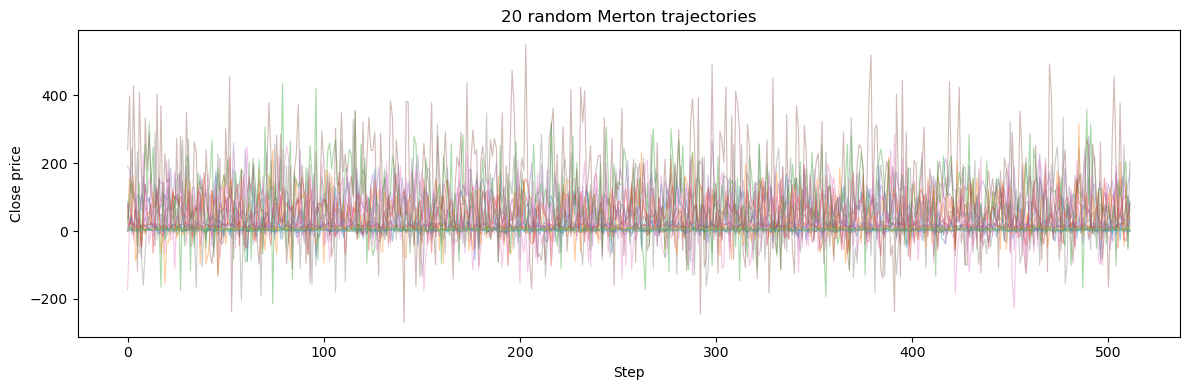

In [2]:
N_TRAJ = 20
rng = np.random.default_rng(42)
idx = rng.choice(len(df), size=N_TRAJ, replace=False)
sample = df.iloc[idx]

prices = sample[step_cols].values          # (N_TRAJ, T)
t = np.arange(prices.shape[1])

fig, ax = plt.subplots(figsize=(12, 4))
for row in prices:
    ax.plot(t, row, alpha=0.4, linewidth=0.8)
ax.set(xlabel='Step', ylabel='Close price', title=f'{N_TRAJ} random Merton trajectories')
plt.tight_layout()
plt.show()

## Log-return distribution

In [ ]:
prices_all = df[step_cols].values          # (N, T)
log_rets = np.diff(np.log(prices_all), axis=1).ravel()   # flatten all steps
log_rets = log_rets[np.isfinite(log_rets)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(log_rets, bins=200, density=True, color='steelblue', alpha=0.8)
axes[0].set(xlabel='Log-return', title='Distribution of log-returns')

# QQ-plot against normal
from scipy import stats
stats.probplot(log_rets, dist='norm', plot=axes[1])
axes[1].set_title('QQ-plot vs Normal')

plt.tight_layout()
plt.show()

print(f'Mean : {log_rets.mean():.6f}')
print(f'Std  : {log_rets.std():.6f}')
print(f'Skew : {stats.skew(log_rets):.4f}')
print(f'Kurt : {stats.kurtosis(log_rets):.4f}  (excess)')

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6432\2654909703.py:2: RuntimeWarning: invalid value encountered in log
  log_rets = np.diff(np.log(prices_all), axis=1).ravel()   # flatten all steps


## Per-file statistics (mean & std of log-returns)

In [ ]:
log_ret_df = pd.DataFrame(
    np.diff(np.log(prices_all), axis=1),
    index=df.index
)
log_ret_df['file'] = df['file'].values

per_file = log_ret_df.groupby('file').apply(
    lambda g: pd.Series({
        'mean_ret': g.drop(columns='file').values.mean(),
        'std_ret' : g.drop(columns='file').values.std(),
    })
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].barh(per_file['file'].str.split('_').str[0], per_file['mean_ret'])
axes[0].set(xlabel='Mean log-return', title='Mean per ticker')
axes[1].barh(per_file['file'].str.split('_').str[0], per_file['std_ret'])
axes[1].set(xlabel='Std log-return', title='Volatility per ticker')

plt.tight_layout()
plt.show()

per_file.head(10)